In [16]:
import pandas as pd
from google.colab import files

# Upload the IRIS.csv file
uploaded = files.upload()

# Check if the file was uploaded
if 'IRIS.csv' in uploaded:
    df = pd.read_csv('IRIS.csv')
    print("File 'IRIS.csv' uploaded and loaded successfully.")
    df.head()
else:
    print("IRIS.csv was not uploaded. Please upload the correct file.")

Saving IRIS.csv to IRIS.csv
File 'IRIS.csv' uploaded and loaded successfully.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All necessary libraries imported.")

All necessary libraries imported.


In [18]:
# Encode the 'species' column
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])
print("Species column encoded. First 5 rows of df:")
print(df.head())

Species column encoded. First 5 rows of df:
   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


In [19]:
# Define features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']
print("Features (X) and target (y) defined.")

Features (X) and target (y) defined.


In [20]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (120, 4)
y_test shape: (30,)


In [21]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
print("Logistic Regression model trained.")

Logistic Regression model trained.


In [22]:
# Make predictions on the test set
prediction = model.predict(X_test)
print("Predictions made.")

Predictions made.


In [23]:
# Calculate and print accuracy score
accuracy = accuracy_score(y_test, prediction)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


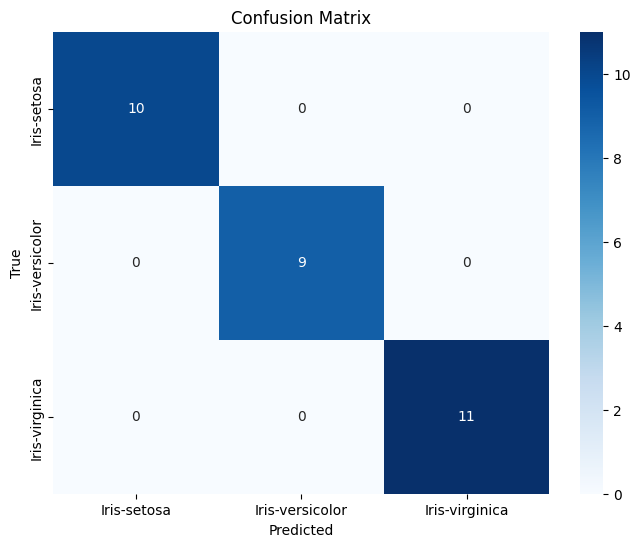

In [24]:
# Calculate and display the Confusion Matrix
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

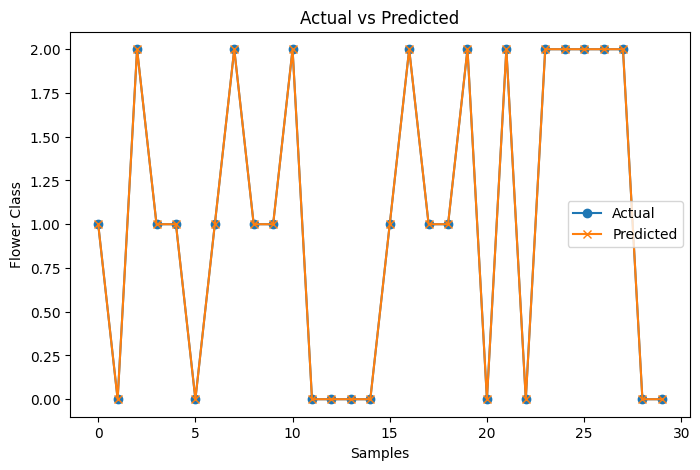

In [29]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values, label="Actual", marker='o')

plt.plot(prediction, label="Predicted", marker='x')

plt.title("Actual vs Predicted")

plt.xlabel("Samples")

plt.ylabel("Flower Class")

plt.legend()

plt.show()






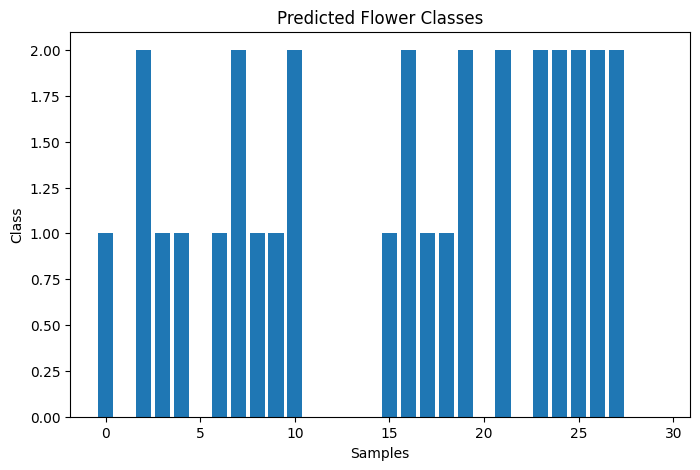

In [25]:
plt.figure(figsize=(8,5))

plt.bar(range(len(prediction)), prediction)

plt.title("Predicted Flower Classes")

plt.xlabel("Samples")

plt.ylabel("Class")

plt.show()

In [26]:
new_data = [[5.1,3.5,1.4,0.2]]

result = model.predict(new_data)

flower = encoder.inverse_transform(result)

print("Predicted Flower:", flower[0])

Predicted Flower: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [27]:
new_data = [[6.7,3.0,5.2,2.3]]

result = model.predict(new_data)

flower = encoder.inverse_transform(result)

print("Predicted Flower:", flower[0])

Predicted Flower: Iris-virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [28]:
import joblib

joblib.dump(model, "iris_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
